<a href="https://colab.research.google.com/github/SergeiVKalinin/MSE_Spring_2026/blob/main/Module%203/Midterm_Spring2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Part 1. Computational modeling

## 1.1 Capacitor discharging in an RC circuit (warm up)

$$RC\frac{dV}{dt}+V=0$$

$R = 1$ Ohm

$C= 1$ F

$V(t=0)=1$



**Q1. Implement 3 time-stepping methods**

Write code to solve $V(t)$ on $t∈[0,T]$ using step size h with:

1) Explicit Euler

2) Runge–Kutta 2nd order (midpoint method)

3) Runge–Kutta 4th order

Use $T=10$ start with $h=1$, then decrease a step to $h=0.1$. Test also intermediate values for $h$

In [ ]:
#fill the gaps in the code below

#problem definition
def rc_rhs(t, V, R=1, C=1):
  return -V/(R*C)

#exact solution(ground truth)
def exact_rc(t, R=1, C=1, v0=1):
  return v0*np.exp(-t/(R*C))


def rk2_step(f, t, y, h):
    k1 = f(t, y)
    k2 = f(t + 0.5*h, y + 0.5*h*k1)
    return y + h * k2

def rk4_step(f, t, y, h):
  pass
  #your code here

def euler_step(f, t, y, h):
    return y + h * f(t, y)

# -----------------------------
# Simulation function
# -----------------------------

def solve_ode(f, y0, T, h, method):
    N = int(T/h)
    t = np.linspace(0, T, N+1)
    y = np.zeros(N+1)
    y[0] = y0

    for n in range(N):
        y[n+1] = method(f, t[n], y[n], h)

    return t, y

In [ ]:
T = 10
h = 1     # different
v0 = 1.0 #V(t=0) = 1

t_e, y_e = solve_ode(rc_rhs, v0, T, h, euler_step)
#t_t2, y_t2 = solve_ode(rc_rhs, y0, T, h, taylor2_step)

#calculate the same for the RK2 and RK4

t_rk2, y_rk2 = solve_ode(rc_rhs, v0, T, h, rk2_step)
t_rk4, y_rk4 = solve_ode(rc_rhs, v0, T, h, rk4_step)


# Exact solution of the ODE (ground truth)
t_exact = np.linspace(0, T, 500)
y_exact = exact_rc(t_exact)

**Q2. Compute the solutions**

1) Compute the numerical solutions for the different methods and $h$ (use at least 3-5 different $h$)
2) Plot the solutions
3) Compare them with the exact solution on the same plot

In [ ]:
#your code

**Q3. Study how error depends on step size**

For each method and each step size compute RMS error over the whole interval:

$RMS_h=\sqrt{\frac{1}{N+1}\sum_{n=1}^{N}{(V_{est}(t_n)-V_{exact}(t_n))^2}}$


1) Plot RMS error vs step size (log–log) for all three methods on the same graph.

2) For each method, estimate how fast the error decreases when $h$ decreases.



$$p=\frac{\log(RMS_{h1}/RMS_{h2})}{\log{(h_1/h_2)}}$$

$p$ tells you the order of the method.

In [ ]:
#your code

## 1.2.  Nonlinear Pendulum

Consider a simple pendulum of length $L$ in gravitational field $g$.

Motion equation:

$$\frac{d^2\theta}{dt^2}+\frac{g}{L}\sin{\theta}=0$$
$$\omega = \frac{d\theta}{dt}$$

$$\frac{d\omega}{dt}= -\frac{g}{L}\sin{\theta}$$

Use:

$g=9.81$ m/s$^2$,
$L=1$ m,
$\theta(t=0)=1.2$ rad,
$\omega(t=0)=0$

Make all simulation for:
$t \in [0, 20]$


**Q2.1 Numerical solutions**

- Solve this equation for $\theta(t)$ numerically with different methods and for the different step size as above.
- Analyse the results

In [ ]:
#your code

**Q2.2 Nonlinear vs Linear Model**

For small angles we may use linear approximation $\sin\theta \approx \theta$:

$$\frac{d^2\theta}{dt^2}+\frac{g}{L}\theta=0$$

- Solve this equation analytically and numerically
- Compare linear and nonlinear models for the small and large angles
- Suggest a quantitative criterion for when the approximation is acceptable and determine the corresponding limit on $\theta_{threshold}$.

In [ ]:
# your code

# Part 2. Data-Driven Model Discovery with Symbolic Regression

In this task you will use symbolic regression to recover governing equations from numerically generated pendulum data.

Symbolic regression is performed using the [PySr](https://astroautomata.com/PySR/v1.5.9/api.html) python package.

In [ ]:
!pip install -U pysr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.3/99.3 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.7/251.7 kB 17.6 MB/s eta 0:00:00


In [ ]:
from pysr import PySRRegressor

In [ ]:
#exampl of the pysr regressor, more details in PySr documentation documentation

model = PySRRegressor(
    niterations=30,
    binary_operators=["+", "*", "/", "-"], #extend if require
    unary_operators=["cos", "exp", "sin"], #extend and refine if require
)

**Q.1 Symbolic Regression with PySR**

- Generate datasets for the small- and large-angle pendulum models from Part 1.2 (obtain $\theta(t)$)

- Create and refine a PySR model (define appropriate unary and binary operators, etc.; see example above and pysr documentation).

- Fit symbolic models separately for:
  - small-angle dataset
  - large-angle dataset
- Analyse and compare the suggested symbolic models.
  - Does each PySR regressor recover: $\frac{d\omega}{dt}= -\frac{g}{L}\theta$ for small angles?
  - Does it recover $\frac{d\omega}{dt}= -\frac{g}{L}\sin{\theta}$ for large angles?
- Do the discovered models generalize to larger amplitudes?

- What criteria does PySR use to select the optimal model?

In [ ]:
#your code

**Q.2 LLM-assisted model selection**

In this task, you will integrate a Large Language Model (Gemini) as a scientific reasoning assistant to evaluate the results of symbolic regression and select the most physically grounded model.

In the previous part, the PySR regressor generated several candidate symbolic expressions describing the dependence of the system. You analyzed the criteria used for selecting the best model based on statistical metrics.

Here, we are going to extent this analysis by incorporating an LLM assistant capable of introducing additional physical reasoning criteria. The goal is to evaluate whether the discovered symbolic models are not only statistically optimal but also physically consistent with known physical laws.


1. Construct a prompt that includes:
  - Short description of the pendulum system
  - Some physical assumptions and constraits
  - Candidate model

2. Design a structured JSON response scheme that Gemini must follow
  - Model index
  - Physics consistency score
  - Flags for potential issues (e.g., symmetry violation, physics violation, etc.)
  
  These criteria are approximate you may propose your own criteria and scheme.
  
3. Call [Gemini API](https://aistudio.google.com/welcome?utm_source=google&utm_medium=cpc&utm_campaign=Cloud-SS-DR-AIS-FY26-global-gsem-1713578&utm_content=text-ad&utm_term=KW_gemini%20api&gad_source=1&gad_campaignid=23417416052&gbraid=0AAAAACn9t67Ls8VCFt52ymzxENtBzpu6I&gclid=Cj0KCQiAtfXMBhDzARIsAJ0jp3BP0TpgyH5ipTdbfM34RlJBObFChM-KAt0veBn04Rh8gTNtYQLYUikaAoqSEALw_wcB) and define the LLM based criteria for the each of the candidate model

4. Define a combined selection criterion, for example: $\alpha*PySR_{score} + (1- \alpha)*LLM_{score}$ and choose the best model.

- Analyse the result, test different joint criteria, different weight ration between the PySr_score and LLM_score.  


In [ ]:
#import gemini api
from google import genai

In [ ]:
#your api key.
#REMOVE YOUR KEY BEFORE SUBMISSION!
api_key = #write your key to connect

client = genai.Client(api_key=api_key, http_options={'api_version': 'v1beta'})

#the simplest query as example
resp = client.models.generate_content(
        model='gemini-2.5-flash',
        contents="Explain why sin(theta) ≈ theta for small angles."
    )

print(resp)

sdk_http_response=HttpResponse(
  headers=<dict len=10>
) candidates=[Candidate(
  content=Content(
    parts=[
      Part(
        text="""The approximation $\sin(\theta) \approx \theta$ for small angles is a fundamental concept in mathematics and physics. It's often called the **small-angle approximation**.

There are several ways to understand why this approximation holds true:

---

### 1. Geometric Intuition (Unit Circle)

This is perhaps the most intuitive way to see it:

1.  **Imagine a Unit Circle:** A circle with a radius of $r=1$.
2.  **Draw an Angle $\theta$:** Let $\theta$ be a small angle originating from the center of the circle, measured counter-clockwise from the positive x-axis.
3.  **Identify $\sin(\theta)$:** In a right-angled triangle formed by the angle, the x-axis, and a vertical line down from the point on the circle, $\sin(\theta)$ is the length of the **opposite side** (the y-coordinate of the point on the circle). Since the hypotenuse is the radius (which is 1

As you can see, an unstructured response is inconvenient to integrate into an explainable workflow. Therefore, we require a structured JSON schema.

In [ ]:
#your code

# Part 3. Hypothesis learning

**System**

We have 2D Ising Model (Simple Description)

The Ising model describes a magnetic material made of spins:

- Each spin can be +1 or −1
- Neighboring spins interact with strength J
  - Stronger J → spins prefer to align
  - Weak J → spins are disordered

At fixed temperature T, changing J changes the effective coupling:

$$K=\frac{J}{T}$$

At a critical value $J_c$, the system undergoes a phase transition from:
- Disordered phase (low magnetization)
- Ordered phase (nonzero magnetization)


**Dataset**

The dataset contains Ising model simulation results for:
-  $C_v(J)$ - specific heat
- $\chi(J)$ - magnitic susceptibility
- $M(J)$ - magnetization

All quantities were obtained from Monte Carlo simulations at a fixed temperature T=2.7 K.

**Tasks**

1. Generate physically motivated hypotheses about functional dependences for $C_v, \chi, M$ using Gemini.
2. Test the hypothesis using symbolic regression
3. Select the best model.
4. Explain your reasoning.

In [ ]:
import pandas as pd

In [ ]:
!gdown https://drive.google.com/file/d/1N4V8yAp26djvijISvm_gJvtja6kOMCRS/view?usp=sharing --fuzzy

Downloading...
From: https://drive.google.com/uc?id=1N4V8yAp26djvijISvm_gJvtja6kOMCRS
To: /content/ising_results.csv
100% 11.5k/11.5k [00:00<00:00, 41.0MB/s]


In [ ]:
df = pd.read_csv('/content/ising_results.csv')

[ColabKernelApp] WARNING | Error caught during object inspection: Can't clean for JSON: <no_default>


In [ ]:
df.head()

,J,SpecificHeat,Magnetization,Susceptibility
0,0.000,0.000000,1.00000,2.105312e-14
1,0.015,0.000016,0.02913,6.734713e-02
2,0.030,0.000048,0.03429,7.151791e-02
3,0.045,0.000121,0.03610,9.269481e-02
4,0.060,0.000254,0.04540,1.794430e-01


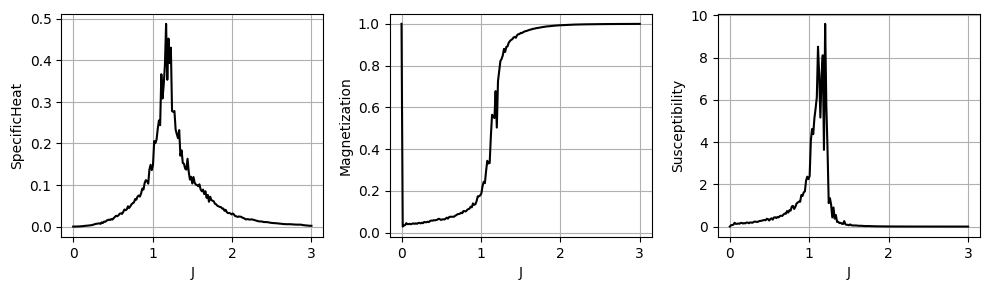

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(10, 3))

ax[0].plot(df['J'], df['SpecificHeat'], 'k')
ax[0].set_ylabel('SpecificHeat')

ax[1].plot(df['J'], df['Magnetization'], 'k')
ax[1].set_ylabel('Magnetization')

ax[2].plot(df['J'], df['Susceptibility'], 'k')
ax[2].set_ylabel('Susceptibility')

for _ in ax:
  _.set_xlabel('J')
  _.grid()

plt.tight_layout()



In [ ]:
#your code

#DO NOT FORGET TO REMOVE YOUR GEMINI API KEY BEFORE SUBMISSION

# Part 4. Mathematical exploration

Here, you will use **ChatGPT as a collaborator** to learn how Runge–Kutta methods are derived, why their coefficients have the constraints they do, and how different coefficient choices change numerical behavior.

The goal is not to copy ChatGPT’s output, but to drive the conversation so that you obtain a correct derivation, translate it into code, and then verify what you learned numerically and visually.

You will work with ODEs of the form
$$
\frac{dy}{dt}=f(t,y),\qquad y(t_0)=y_0.
$$




---

### RK2: derive it with ChatGPT, then validate it yourself

Begin by asking ChatGPT to derive a second-order Runge–Kutta method from first principles, starting from the two-stage explicit form
$$
k_1=f(t_n,y_n),\qquad
k_2=f\!\left(t_n+a h,\; y_n+a h k_1\right),\qquad
y_{n+1}=y_n+h\left(b_1k_1+b_2k_2\right).
$$
Use ChatGPT to produce a Taylor-series matching derivation. Your notebook must clearly show the Taylor expansion of the exact solution $$y(t_n+h)$$ and the Taylor expansion of the numerical update, and then show how equating coefficients yields the RK2 constraints. The end result should be the two second-order conditions
$$
b_1+b_2=1,\qquad a\,b_2=\frac{1}{2}.
$$
These conditions must appear as the conclusion of your derivation, not as a stated fact.



Once you have these constraints, use ChatGPT to help you identify and write down multiple concrete RK2 schemes that satisfy them. Your notebook should include at least the midpoint method, Heun’s (explicit trapezoid / improved Euler) method, and Ralston’s method. For each one, you should write the coefficients $$(a,b_1,b_2)$$ and the corresponding update equations.

Next, push the derivation one order deeper. Use ChatGPT to compute the $$O(h^3)$$ term of the RK2 update and the resulting leading local truncation error term. Your notebook should state the result in a consistent notation, for example using derivatives $$f_t,f_y,f_{tt},f_{ty},f_{yy}$$ evaluated at $$(t_n,y_n)$$, or using elementary differentials / rooted-tree notation. You should explicitly explain, in your own words, why a two-stage explicit RK method cannot generally achieve third order.




---

### RK2 illustration: show the intermediate vectors and what the method is “doing”

After the algebra, build intuition by making a graphic illustration. Use Python to generate at least one figure that shows \(y_n\), the stage point \((t^\*,y^\*)\), the intermediate slopes \(k_1\) and \(k_2\), and the final update to \(y_{n+1}\). You may do this either as a phase-space vector illustration for a simple \(2\)D system, or as a geometry-in-the-\((t,y)\)-plane illustration for a scalar ODE where arrows depict slopes over a short \(\Delta t\). The figure must make the role of the stage evaluation visually obvious.

Then run a convergence check. Choose a smooth ODE whose solution stays finite on your chosen interval (avoid blow-up unless you explicitly analyze it). Generate a high-quality reference solution (for example, RK4 with a very small step size) and demonstrate that the global error of each RK2 scheme scales as \(O(h^2)\). Your notebook should include a plot (log–log is recommended) or a computed slope estimate supporting second-order convergence, and a brief interpretation of which RK2 variant performs better on your test problem and why.



---

### RK4: repeat the process at higher order and learn the coefficient constraints

Now repeat the same learning workflow for fourth-order Runge–Kutta methods. Begin by asking ChatGPT to write the general four-stage explicit RK method and its Butcher tableau:
\[
\begin{array}{c|cccc}
0   & 0     & 0     & 0     & 0\\
c_2 & a_{21}& 0     & 0     & 0\\
c_3 & a_{31}& a_{32}& 0     & 0\\
c_4 & a_{41}& a_{42}& a_{43}& 0\\
\hline
    & b_1   & b_2   & b_3   & b_4
\end{array}
\]
with stages
$$
k_i=f\!\left(t_n+c_i h,\;y_n+h\sum_{j<i}a_{ij}k_j\right),\qquad
y_{n+1}=y_n+h\sum_{i=1}^4 b_i k_i.
$$
Use ChatGPT to derive and clearly state the order conditions required for fourth-order accuracy. You may derive them via Taylor matching or via rooted-tree/Butcher order conditions, but your notebook must present the constraints explicitly and coherently as equations on \(a_{ij},b_i,c_i\). Include a short explanation of what these constraints mean conceptually, e.g. that they enforce agreement of the numerical and exact B-series through order \(4\).

After you have the constraints, use them to recover two distinct RK4 methods. Your notebook must include the classical RK4 method and the \(3/8\)-rule method, written as explicit tableaux and as explicit update equations.

---

### Implementation requirement: one generic RK engine

Your code must include a generic implementation of explicit Runge–Kutta methods that accepts a Butcher tableau \((A,b,c)\) and advances the solution. You will then instantiate RK2 variants and RK4 variants by passing different coefficient sets into the same integrator. You should learn how RK methods are parameterized and how families of schemes emerge from coefficient choices.